# Lab 3 — Simulation and Statistical Methods

**Course:** Programming and Numerical Methods for Economics (ECNM10115)
**University of Edinburgh**

**Purpose:** This lab introduces the simulation and statistical techniques
you need for **Problem Set B** (Questions 3–6 and 8–10).  You will learn
to generate random numbers, run Monte Carlo experiments, simulate AR(1)
processes and Markov chains, and apply bootstrap methods.

**Topics covered:**

1. Random number generation and distributions
2. Monte Carlo integration
3. AR(1) processes
4. Markov chains
5. Bootstrap confidence intervals
6. Variance reduction — antithetic variates


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)


---
## 1. Random number generation and distributions

NumPy's `np.random` module generates pseudo-random numbers from many
distributions.  The key idea: set `np.random.seed(n)` for reproducibility.

| Distribution | Code | Parameters |
|-------------|------|------------|
| Uniform(0,1) | `np.random.uniform(0, 1, n)` | low, high, size |
| Normal | `np.random.normal(mu, sigma, n)` | mean, std, size |
| Log-normal | `np.random.lognormal(mu, sigma, n)` | log-mean, log-std |
| Discrete | `np.random.choice(vals, n, p=probs)` | values, size, probs |


### Worked example

Sample mean:   4.9957  (theory: 5)
Sample std:    2.0068  (theory: 2)


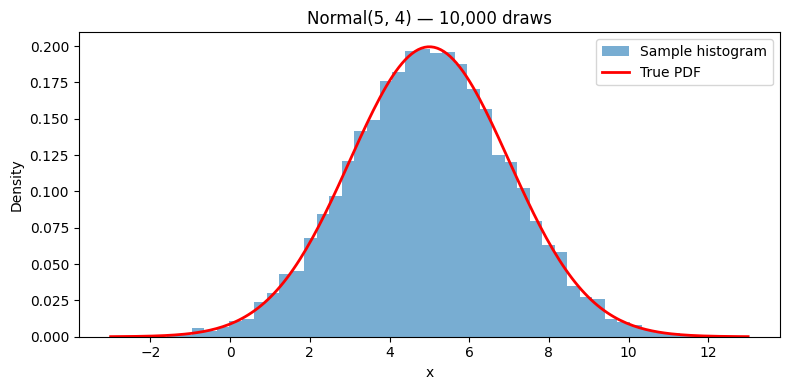

In [2]:
# Draw from a Normal distribution
np.random.seed(42)
draws = np.random.normal(mu := 5, sigma := 2, size := 10_000)

print(f"Sample mean:   {draws.mean():.4f}  (theory: {mu})")
print(f"Sample std:    {draws.std():.4f}  (theory: {sigma})")

# Histogram with true PDF overlay
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(draws, bins=50, density=True, alpha=0.6, label="Sample histogram")

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label="True PDF")
ax.set_xlabel("x"); ax.set_ylabel("Density")
ax.set_title("Normal(5, 4) — 10,000 draws"); ax.legend()
plt.tight_layout(); plt.show()


### ✏️ Exercise 1

1. Draw 10,000 samples from a **Uniform(0, 10)** distribution.
   Compute the sample mean and compare to the theoretical mean (5.0).
2. Draw 10,000 samples from $X \sim N(0, 1)$ and compute $Y = e^X$.
   Compare `Y.mean()` to the theoretical mean $e^{1/2} \approx 1.6487$.
3. Simulate 10,000 quarterly GDP growth rates from the discrete distribution:

   | Growth | −2% | 0% | 1% | 3% |
   |--------|-----|----|----|-----|
   | Prob   | 0.10 | 0.25 | 0.40 | 0.25 |

   Compute the simulated mean and variance, and compare to theory.


In [3]:
# Your answer here


### Solution

In [4]:
# --- Solution ---
np.random.seed(42)

# 1. Uniform
u = np.random.uniform(0, 10, 10_000)
print(f"1. Uniform mean: {u.mean():.4f} (theory: 5.0)")

# 2. Log-normal from exp(Normal)
X = np.random.normal(0, 1, 10_000)
Y = np.exp(X)
print(f"2. E[e^X] sample: {Y.mean():.4f}, theory: {np.exp(0.5):.4f}")

# 3. Discrete distribution
values = np.array([-2, 0, 1, 3])
probs = np.array([0.10, 0.25, 0.40, 0.25])
draws = np.random.choice(values, size=10_000, p=probs)

E_theory = np.sum(values * probs)
Var_theory = np.sum(probs * (values - E_theory)**2)
print(f"3. E[g] sample: {draws.mean():.4f}, theory: {E_theory:.4f}")
print(f"   Var[g] sample: {draws.var():.4f}, theory: {Var_theory:.4f}")


1. Uniform mean: 4.9416 (theory: 5.0)
2. E[e^X] sample: 1.6661, theory: 1.6487
3. E[g] sample: 0.9302, theory: 0.9500
   Var[g] sample: 2.1175, theory: 2.1475


---
## 2. Monte Carlo integration

To estimate $\theta = E[g(X)]$ where $X \sim f$, draw $n$ samples and compute:

$$\hat{\theta}_n = \frac{1}{n} \sum_{i=1}^{n} g(X_i)$$

By the **law of large numbers**, $\hat{\theta}_n \to \theta$ as $n \to \infty$.

The standard error is $\text{SE} \approx s / \sqrt{n}$, so accuracy improves
like $O(1/\sqrt{n})$ — you need 4× the draws for 2× the precision.


### Worked example

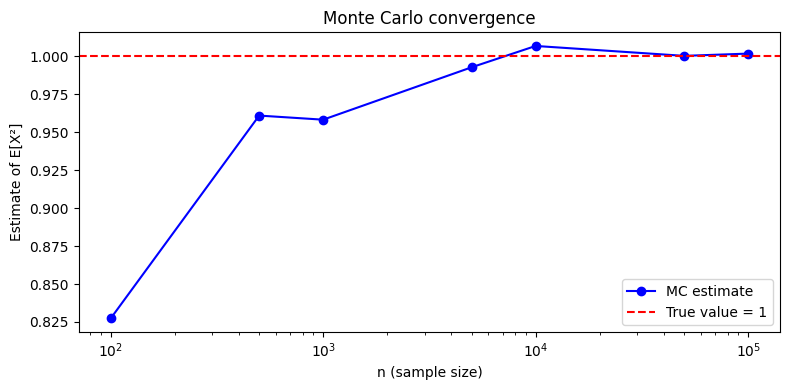

In [5]:
# Estimate E[X^2] where X ~ N(0,1).  True value = 1.
np.random.seed(42)

def mc_estimate(g, n, seed=None):
    """Monte Carlo estimate of E[g(X)] where X ~ N(0,1)."""
    if seed is not None:
        np.random.seed(seed)
    X = np.random.normal(0, 1, n)
    return np.mean(g(X))

# Convergence study
ns = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
estimates = [mc_estimate(lambda x: x**2, n, seed=42) for n in ns]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(ns, estimates, 'bo-', label="MC estimate")
ax.axhline(1.0, color='r', ls='--', label="True value = 1")
ax.set_xlabel("n (sample size)"); ax.set_ylabel("Estimate of E[X²]")
ax.set_title("Monte Carlo convergence"); ax.legend()
plt.tight_layout(); plt.show()


### ✏️ Exercise 2

Estimate $\theta = E[X^2 + \sin(X)]$ where $X \sim N(0,1)$.

The true value is $E[X^2] + E[\sin(X)] = 1 + e^{-1/2}\sin(1) \approx 1.5109$.

1. Estimate $\theta$ with $n = 100{,}000$.
2. Repeat the estimation $M = 1{,}000$ times (each with fresh draws of size $n = 10{,}000$).
   Plot a histogram of the estimates and compute a 95% confidence interval from the
   2.5th and 97.5th percentiles.


In [6]:
# Your answer here


### Solution

1. MC estimate: 1.002421, True: 1.510378


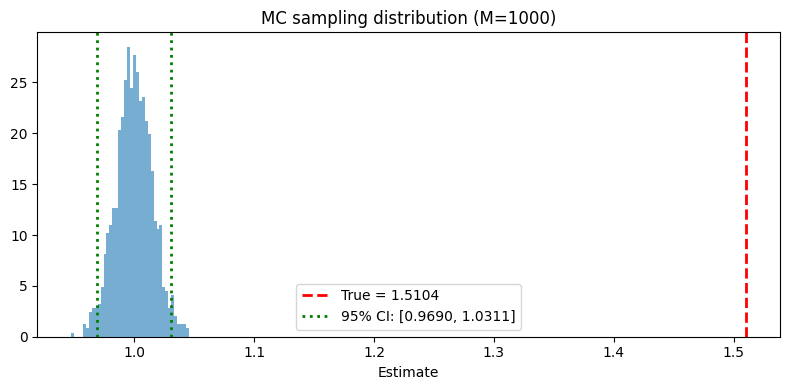

2. 95% CI: [0.9690, 1.0311]
   True value inside CI: False


In [7]:
# --- Solution ---
np.random.seed(42)
g = lambda x: x**2 + np.sin(x)
true_val = 1 + np.exp(-0.5) * np.sin(1)

# 1. Single estimate
est = mc_estimate(g, 100_000, seed=42)
print(f"1. MC estimate: {est:.6f}, True: {true_val:.6f}")

# 2. Repeated estimation
M = 1000
n = 10_000
estimates = [np.mean(g(np.random.normal(0, 1, n))) for _ in range(M)]
ci_low, ci_high = np.percentile(estimates, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(estimates, bins=40, density=True, alpha=0.6)
ax.axvline(true_val, color='r', ls='--', lw=2, label=f"True = {true_val:.4f}")
ax.axvline(ci_low, color='g', ls=':', lw=2, label=f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
ax.axvline(ci_high, color='g', ls=':', lw=2)
ax.set_xlabel("Estimate"); ax.set_title("MC sampling distribution (M=1000)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"2. 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"   True value inside CI: {ci_low <= true_val <= ci_high}")


---
## 3. AR(1) processes

An **AR(1)** (autoregressive of order 1) process models persistence in
economic time series:

$$y_t = \rho \, y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma^2)$$

- If $|\rho| < 1$: **stationary** — the series fluctuates around zero with
  variance $\sigma^2 / (1 - \rho^2)$.
- If $\rho = 1$: **random walk** — the series wanders without bound.


### Worked example

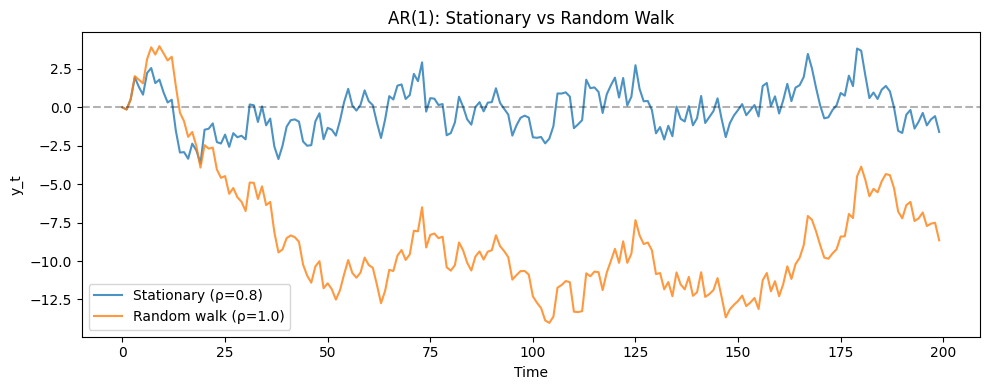

In [8]:
def simulate_ar1(rho, sigma, T, seed=None):
    """Simulate an AR(1) process y_t = rho * y_{t-1} + eps_t."""
    if seed is not None:
        np.random.seed(seed)
    y = np.zeros(T)
    eps = np.random.normal(0, sigma, T)
    for t in range(1, T):
        y[t] = rho * y[t-1] + eps[t]
    return y

# Compare stationary vs random walk
T = 200
y_stat = simulate_ar1(0.8, 1.0, T, seed=42)
y_rw = simulate_ar1(1.0, 1.0, T, seed=42)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_stat, label="Stationary (ρ=0.8)", alpha=0.8)
ax.plot(y_rw, label="Random walk (ρ=1.0)", alpha=0.8)
ax.axhline(0, color='k', ls='--', alpha=0.3)
ax.set_xlabel("Time"); ax.set_ylabel("y_t")
ax.set_title("AR(1): Stationary vs Random Walk")
ax.legend(); plt.tight_layout(); plt.show()


### ✏️ Exercise 3

1. Simulate an AR(1) with $\rho = 0.9$, $\sigma = 1$, $T = 500$.
2. Compute the sample variance and compare to the theoretical variance
   $\sigma^2 / (1 - \rho^2)$.
3. Compute the sample autocorrelation at lags 1 to 5 and compare to $\rho^k$.

*Hint:* The sample autocorrelation at lag $k$ is
$\hat{\rho}_k = \frac{\sum_{t=k+1}^{T} (y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T} (y_t - \bar{y})^2}$


In [9]:
# Your answer here


### Solution

In [10]:
# --- Solution ---
np.random.seed(42)
rho, sigma, T = 0.9, 1.0, 500
y = simulate_ar1(rho, sigma, T, seed=42)

# 2. Variance comparison
var_sample = np.var(y)
var_theory = sigma**2 / (1 - rho**2)
print(f"Sample variance: {var_sample:.4f}")
print(f"Theory variance: {var_theory:.4f}")

# 3. Autocorrelations
y_demean = y - y.mean()
denom = np.sum(y_demean**2)
for k in range(1, 6):
    acf_sample = np.sum(y_demean[k:] * y_demean[:-k]) / denom
    acf_theory = rho**k
    print(f"Lag {k}: sample = {acf_sample:.4f}, theory = {acf_theory:.4f}")


Sample variance: 4.3792
Theory variance: 5.2632
Lag 1: sample = 0.8831, theory = 0.9000
Lag 2: sample = 0.7780, theory = 0.8100
Lag 3: sample = 0.6846, theory = 0.7290
Lag 4: sample = 0.5961, theory = 0.6561
Lag 5: sample = 0.5334, theory = 0.5905


---
## 4. Markov chains

A **Markov chain** is a stochastic process where the next state depends only
on the current state, not the history.  It is defined by:

- A set of states $S = \{0, 1, \ldots, n-1\}$
- A **transition matrix** $P$ where $P_{ij} = \Pr(s_{t+1} = j \mid s_t = i)$

The **stationary distribution** $\pi$ satisfies $\pi P = \pi$ and
$\sum_i \pi_i = 1$.  In the long run, the fraction of time spent in state $i$
converges to $\pi_i$.

You can simulate manually with `np.random.choice`, or use the
`quantecon.MarkovChain` class.


### Worked example

Empirical:   [0.7506 0.2494]
Theoretical: [0.75 0.25]


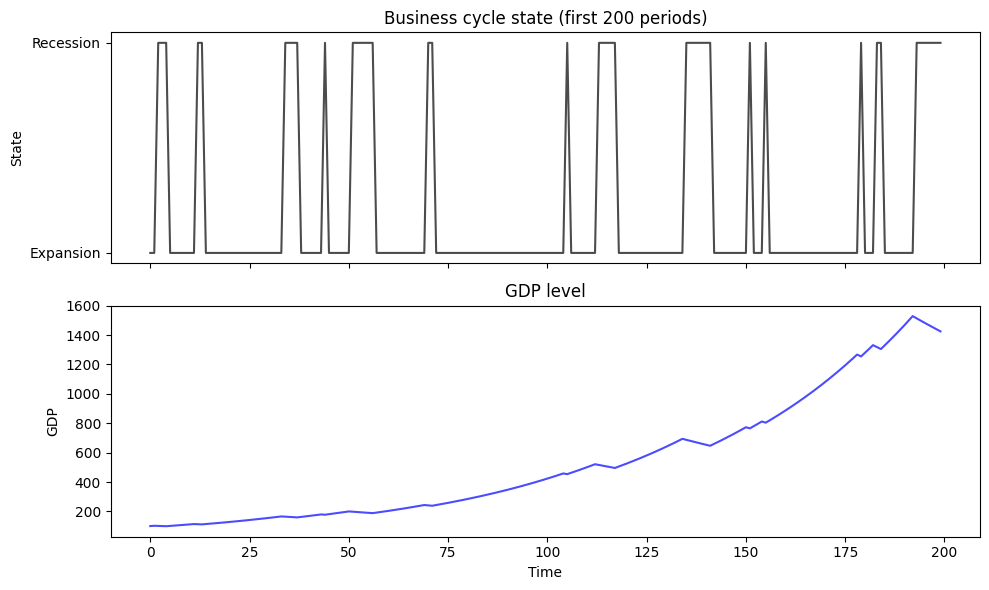

In [11]:
# Two-state business cycle: Expansion (0) and Recession (1)
P = np.array([[0.90, 0.10],
              [0.30, 0.70]])

# Manual simulation
def simulate_markov(P, T, s0=0, seed=None):
    """Simulate a Markov chain for T periods."""
    if seed is not None:
        np.random.seed(seed)
    states = np.zeros(T, dtype=int)
    states[0] = s0
    n_states = P.shape[0]
    for t in range(1, T):
        states[t] = np.random.choice(n_states, p=P[states[t-1]])
    return states

T = 5000
states = simulate_markov(P, T, s0=0, seed=42)

# Empirical vs theoretical stationary distribution
empirical = np.array([np.mean(states == i) for i in range(2)])

# Solve pi @ P = pi analytically
# pi_0 * 0.90 + pi_1 * 0.30 = pi_0  →  pi_1 * 0.30 = pi_0 * 0.10
# pi_0 + pi_1 = 1  →  pi_0 = 0.75, pi_1 = 0.25
pi_theory = np.array([0.75, 0.25])

print(f"Empirical:   {empirical}")
print(f"Theoretical: {pi_theory}")

# GDP path with regime-dependent growth
growth_rates = np.where(states == 0, 2.0, -1.0)  # 2% in Expansion, -1% in Recession
gdp = np.zeros(T)
gdp[0] = 100
for t in range(1, T):
    gdp[t] = gdp[t-1] * (1 + growth_rates[t] / 100)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(states[:200], 'k-', alpha=0.7)
axes[0].set_ylabel("State"); axes[0].set_title("Business cycle state (first 200 periods)")
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Expansion", "Recession"])

axes[1].plot(gdp[:200], 'b-', alpha=0.7)
axes[1].set_xlabel("Time"); axes[1].set_ylabel("GDP")
axes[1].set_title("GDP level"); plt.tight_layout(); plt.show()


### ✏️ Exercise 4

Consider a three-state Markov chain:

$$P = \begin{pmatrix} 0.7 & 0.2 & 0.1 \\ 0.1 & 0.8 & 0.1 \\ 0.05 & 0.25 & 0.7 \end{pmatrix}$$

States: 0 = Recession, 1 = Normal, 2 = Boom.

1. Simulate $T = 2{,}000$ periods starting from state 1 (Normal).
2. Compute the empirical fraction of time in each state.
3. Find the stationary distribution by computing the left eigenvector of $P$
   (use `np.linalg.eig(P.T)` and normalise so elements sum to 1).
4. Compare the empirical and theoretical distributions.


In [12]:
# Your answer here


### Solution

In [13]:
# --- Solution ---
np.random.seed(42)
P3 = np.array([[0.7, 0.2, 0.1],
               [0.1, 0.8, 0.1],
               [0.05, 0.25, 0.7]])

# 1. Simulate
states3 = simulate_markov(P3, 2000, s0=1, seed=42)

# 2. Empirical fractions
empirical3 = np.array([np.mean(states3 == i) for i in range(3)])
print(f"Empirical: {empirical3}")

# 3. Stationary distribution via eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(P3.T)
# Find the eigenvector for eigenvalue ≈ 1
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi3 = np.real(eigenvectors[:, idx])
pi3 = pi3 / pi3.sum()  # normalise
print(f"Theoretical: {np.round(pi3, 4)}")

# 4. Compare
print(f"Difference:  {np.round(empirical3 - pi3, 4)}")


Empirical: [0.2275 0.515  0.2575]
Theoretical: [0.2188 0.5312 0.25  ]
Difference:  [ 0.0087 -0.0162  0.0075]


---
## 5. Bootstrap confidence intervals

The **bootstrap** estimates a statistic's sampling distribution by
resampling **with replacement** from the original data.

Algorithm for a 95% CI on the mean:
1. From your sample of size $n$, draw $B$ bootstrap samples (each size $n$, with replacement).
2. Compute the mean of each bootstrap sample.
3. Take the 2.5th and 97.5th percentiles of the $B$ means.


### Worked example

In [14]:
np.random.seed(42)

def bootstrap_ci(data, stat_func=np.mean, B=5000, alpha=0.05):
    """Bootstrap confidence interval for any statistic."""
    n = len(data)
    boot_stats = np.array([
        stat_func(np.random.choice(data, size=n, replace=True))
        for _ in range(B)
    ])
    lower = np.percentile(boot_stats, 100 * alpha / 2)
    upper = np.percentile(boot_stats, 100 * (1 - alpha / 2))
    return lower, upper, boot_stats

# Generate skewed income data
incomes = np.random.lognormal(10.5, 0.8, 200)
print(f"Sample mean: £{incomes.mean():,.0f}")
print(f"Sample median: £{np.median(incomes):,.0f}")

# Bootstrap CI for the mean
lo, hi, boot_means = bootstrap_ci(incomes, B=10_000)
print(f"\n95% Bootstrap CI for the mean: [£{lo:,.0f}, £{hi:,.0f}]")

# Compare with normal-approximation CI
se = incomes.std() / np.sqrt(len(incomes))
lo_norm = incomes.mean() - 1.96 * se
hi_norm = incomes.mean() + 1.96 * se
print(f"Normal-approx CI: [£{lo_norm:,.0f}, £{hi_norm:,.0f}]")
print("(The bootstrap CI may be asymmetric for skewed data)")


Sample mean: £46,734
Sample median: £36,195



95% Bootstrap CI for the mean: [£41,054, £52,725]
Normal-approx CI: [£40,923, £52,544]
(The bootstrap CI may be asymmetric for skewed data)


### ✏️ Exercise 5

Generate 150 observations from an Exponential distribution with rate $\lambda = 0.5$
(i.e., mean = 2):

```python
data = np.random.exponential(scale=2.0, size=150)
```

1. Compute the bootstrap 95% CI for the **median** using $B = 10{,}000$ resamples.
2. Plot the bootstrap distribution of the median.
3. Is the bootstrap distribution symmetric or skewed?  Why?


In [15]:
# Your answer here


### Solution

Sample median: 1.1890
95% Bootstrap CI for median: [0.8531, 1.4836]


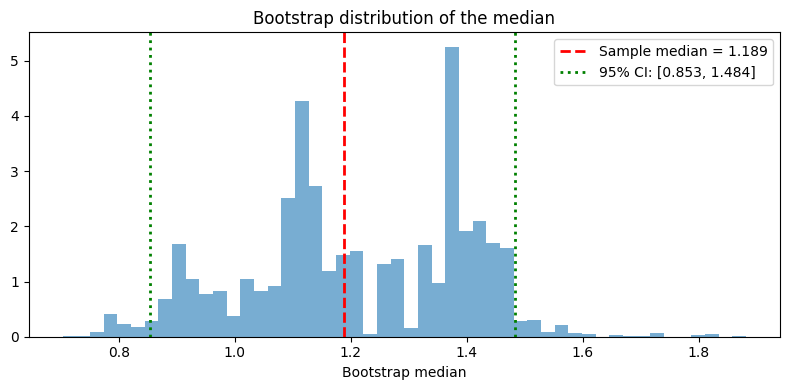


Skewness: -0.142
Slightly right-skewed because the Exponential distribution is right-skewed,
and the median inherits some of that asymmetry.


In [16]:
# --- Solution ---
np.random.seed(42)
data = np.random.exponential(scale=2.0, size=150)

# 1. Bootstrap CI for the median
lo, hi, boot_medians = bootstrap_ci(data, stat_func=np.median, B=10_000)
print(f"Sample median: {np.median(data):.4f}")
print(f"95% Bootstrap CI for median: [{lo:.4f}, {hi:.4f}]")

# 2. Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_medians, bins=50, density=True, alpha=0.6)
ax.axvline(np.median(data), color='r', ls='--', lw=2, label=f"Sample median = {np.median(data):.3f}")
ax.axvline(lo, color='g', ls=':', lw=2, label=f"95% CI: [{lo:.3f}, {hi:.3f}]")
ax.axvline(hi, color='g', ls=':', lw=2)
ax.set_xlabel("Bootstrap median"); ax.set_title("Bootstrap distribution of the median")
ax.legend(); plt.tight_layout(); plt.show()

# 3. Skewness
skew = stats.skew(boot_medians)
print(f"\nSkewness: {skew:.3f}")
print("Slightly right-skewed because the Exponential distribution is right-skewed,")
print("and the median inherits some of that asymmetry.")


---
## 6. Variance reduction — antithetic variates

When estimating $\theta = E[h(X)]$ with $X \sim N(0,1)$, we can reduce
variance by pairing each draw $X_i$ with $-X_i$:

$$\hat{\theta}_{\text{AV}} = \frac{1}{n/2} \sum_{i=1}^{n/2} \frac{h(X_i) + h(-X_i)}{2}$$

This works because $h(X)$ and $h(-X)$ are **negatively correlated** when $h$
is monotone, so their average has lower variance than two independent draws.


### Worked example

In [17]:
np.random.seed(42)

# Estimate E[e^X] where X ~ N(0,1).  True value = e^{1/2} ≈ 1.6487
true_val = np.exp(0.5)

def naive_mc(n):
    X = np.random.normal(0, 1, n)
    return np.mean(np.exp(X))

def antithetic_mc(n):
    X = np.random.normal(0, 1, n // 2)
    return np.mean((np.exp(X) + np.exp(-X)) / 2)

print(f"Naive MC (n=100k):      {naive_mc(100_000):.6f}")
print(f"Antithetic MC (n=100k): {antithetic_mc(100_000):.6f}")
print(f"True value:             {true_val:.6f}")

# Variance comparison
M = 2000
n = 10_000
naive_ests = [naive_mc(n) for _ in range(M)]
anti_ests = [antithetic_mc(n) for _ in range(M)]

var_naive = np.var(naive_ests)
var_anti = np.var(anti_ests)
print(f"\nNaive variance:     {var_naive:.8f}")
print(f"Antithetic variance: {var_anti:.8f}")
print(f"Variance reduction factor: {var_naive / var_anti:.1f}x")


Naive MC (n=100k):      1.650402
Antithetic MC (n=100k): 1.646779
True value:             1.648721



Naive variance:     0.00043912
Antithetic variance: 0.00028731
Variance reduction factor: 1.5x


### ✏️ Exercise 6

Estimate $\theta = E[X^4]$ where $X \sim N(0,1)$.  The true value is $3$
(the fourth moment of the standard normal).

1. Implement naive and antithetic estimators.
2. Estimate $\theta$ with $n = 50{,}000$ using each method.
3. Repeat $M = 1{,}000$ times with $n = 10{,}000$ and compare the variances.
4. Is the variance reduction large or small?  Why?

*Hint:* Think about whether $X^4$ and $(-X)^4$ are positively or negatively
correlated.


In [18]:
# Your answer here


### Solution

In [19]:
# --- Solution ---
np.random.seed(42)
true_val = 3.0  # E[X^4] for X ~ N(0,1)

def naive_x4(n):
    X = np.random.normal(0, 1, n)
    return np.mean(X**4)

def anti_x4(n):
    X = np.random.normal(0, 1, n // 2)
    return np.mean((X**4 + (-X)**4) / 2)

# 2. Single estimates
print(f"Naive (n=50k):      {naive_x4(50_000):.4f}")
print(f"Antithetic (n=50k): {anti_x4(50_000):.4f}")
print(f"True value:         {true_val}")

# 3. Variance comparison
M, n = 1000, 10_000
naive_ests = [naive_x4(n) for _ in range(M)]
anti_ests = [anti_x4(n) for _ in range(M)]

var_n = np.var(naive_ests)
var_a = np.var(anti_ests)
print(f"\nNaive variance:     {var_n:.6f}")
print(f"Antithetic variance: {var_a:.6f}")
print(f"Ratio: {var_n / var_a:.2f}x")

# 4. Explanation
print("\nThe variance reduction is essentially 1x (no improvement).")
print("This is because X^4 = (-X)^4 — the function is symmetric,")
print("so h(X) and h(-X) are perfectly positively correlated.")
print("Antithetic variates only help when h is monotone (not symmetric).")


Naive (n=50k):      3.0030
Antithetic (n=50k): 2.9984
True value:         3.0



Naive variance:     0.009226
Antithetic variance: 0.018552
Ratio: 0.50x

The variance reduction is essentially 1x (no improvement).
This is because X^4 = (-X)^4 — the function is symmetric,
so h(X) and h(-X) are perfectly positively correlated.
Antithetic variates only help when h is monotone (not symmetric).


---
## Summary

You now have the simulation and statistical toolkit for **Problem Set B**:

| Concept | PS B Questions |
|---------|---------------|
| Random numbers, distributions | Q3 |
| Monte Carlo integration | Q4 |
| AR(1) processes | Q5 |
| Markov chains | Q6, Q10 |
| Bootstrap CI | Q8 |
| Antithetic variates | Q9 |
| Combining everything | Q10 (regime-switching GDP) |

Head to Problem Set B and tackle Questions 3–6 and 8–10!
